<a href="https://colab.research.google.com/github/bosywahab818-a11y/flyrank-ml-internship-bouthina/blob/main/FlyRank_ML_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Search Ranking & Discoverability Capstone

## Refresh / Content Opportunity Scoring

### Research Question

Can we build a machine learning model that ranks content by refresh opportunity using current search-performance and freshness signals?

### Objective

This project develops a decision-support system that ranks content for potential refresh or review. A rule-based baseline is compared with a machine learning model using current snapshot features and a future performance outcome.

The goal is not to prove causality or explain Google's ranking algorithm, but to identify measurable patterns that can support content review decisions.v

In [1]:
import pandas as pd
import numpy as np
import os

DATA_PATH = "data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/content_refresh_anonymized.csv'

In [3]:
!git clone "https://github.com/bosywahab818-a11y/flyrank-ml-internship-bouthina.git"

Cloning into 'flyrank-ml-internship-bouthina'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 131 (delta 43), reused 94 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 1.87 MiB | 9.99 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [4]:
%cd /content/flyrank-ml-internship-bouthina

/content/flyrank-ml-internship-bouthina


In [5]:
import os

print("Current folder:", os.getcwd())
print("Raw files:", os.listdir("data/raw"))

Current folder: /content/flyrank-ml-internship-bouthina
Raw files: ['content_refresh_anonymized.csv']


In [6]:
import pandas as pd
import numpy as np

DATA_PATH = "data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [7]:
display(df.head())

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [9]:
# Check the previous vs last 30-day performance

window_cols = [
    "impressions_prev_30d",
    "impressions_last_30d",
    "clicks_prev_30d",
    "clicks_last_30d",
    "sessions_prev_30d",
    "sessions_last_30d"
]

display(df[window_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
impressions_prev_30d,30000.0,1783.078500,6150.429511,0.0,19.0,210.0,1143.0,218786.0
impressions_last_30d,30000.0,1429.058733,5643.852081,0.0,10.0,139.0,768.0,238796.0
clicks_prev_30d,30000.0,5.435100,28.358673,0.0,0.0,0.0,2.0,1627.0
clicks_last_30d,30000.0,4.933867,23.929393,0.0,0.0,0.0,2.0,1176.0
sessions_prev_30d,30000.0,10.283000,42.578003,0.0,1.0,2.0,7.0,4247.0
sessions_last_30d,30000.0,14.114267,39.036371,0.0,0.0,3.0,12.0,1081.0


In [10]:
# Calculate changes between the two windows

df["impression_change_pct"] = np.where(
    df["impressions_prev_30d"] > 0,
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / df["impressions_prev_30d"] * 100,
    np.nan
)

df["click_change_pct"] = np.where(
    df["clicks_prev_30d"] > 0,
    (df["clicks_last_30d"] - df["clicks_prev_30d"])
    / df["clicks_prev_30d"] * 100,
    np.nan
)

df["session_change_pct"] = np.where(
    df["sessions_prev_30d"] > 0,
    (df["sessions_last_30d"] - df["sessions_prev_30d"])
    / df["sessions_prev_30d"] * 100,
    np.nan
)

display(
    df[
        [
            "impression_change_pct",
            "click_change_pct",
            "session_change_pct"
        ]
    ].describe()
)

,impression_change_pct,click_change_pct,session_change_pct
count,26612.000000,11759.000000,23271.000000
mean,-4.785741,0.336466,58.036674
std,473.861561,130.783853,214.989488
min,-100.000000,-100.000000,-100.000000
25%,-62.632201,-76.470588,-66.666667
50%,-33.464585,-25.000000,0.000000
75%,0.000000,22.222222,100.000000
max,44900.000000,2500.000000,3100.000000


In [11]:
# Check how many rows have usable previous-window data

print("Rows with previous impressions > 0:",
      (df["impressions_prev_30d"] > 0).sum())

print("Rows with previous clicks > 0:",
      (df["clicks_prev_30d"] > 0).sum())

print("Rows with previous sessions > 0:",
      (df["sessions_prev_30d"] > 0).sum())

Rows with previous impressions > 0: 26612
Rows with previous clicks > 0: 11759
Rows with previous sessions > 0: 23271


In [12]:
# Define the future-window target

TARGET_DECLINE = -30

model_df = df[df["impressions_prev_30d"] > 0].copy()

model_df["target_refresh"] = (
    model_df["impression_change_pct"] <= TARGET_DECLINE
).astype(int)

print("Rows available for modeling:", len(model_df))
print("\nTarget distribution:")
print(model_df["target_refresh"].value_counts())

print("\nTarget percentage:")
print(model_df["target_refresh"].value_counts(normalize=True) * 100)

Rows available for modeling: 26612

Target distribution:
target_refresh
1    14129
0    12483
Name: count, dtype: int64

Target percentage:
target_refresh
1    53.09259
0    46.90741
Name: proportion, dtype: float64


In [13]:
# Inspect the target against the actual change

display(
    model_df.groupby("target_refresh")["impression_change_pct"]
    .agg(["count", "mean", "median", "min", "max"])
)

,count,mean,median,min,max
target_refresh,,,,,
0,12483,61.212127,1.960784,-29.9965,44900.0
1,14129,-63.094990,-60.671798,-100.0000,-30.0


In [14]:
# Define the modeling dataset and target

TARGET_DECLINE = -30

model_df = df[df["impressions_prev_30d"] > 0].copy()

model_df["target_refresh"] = (
    model_df["impression_change_pct"] <= TARGET_DECLINE
).astype(int)

print("Modeling rows:", len(model_df))
print("\nTarget distribution:")
print(model_df["target_refresh"].value_counts())

print("\nTarget percentage:")
print(
    (model_df["target_refresh"].value_counts(normalize=True) * 100)
    .round(2)
)

Modeling rows: 26612

Target distribution:
target_refresh
1    14129
0    12483
Name: count, dtype: int64

Target percentage:
target_refresh
1    53.09
0    46.91
Name: proportion, dtype: float64


In [15]:
# Verify that the target actually represents a meaningful decline

target_check = (
    model_df.groupby("target_refresh")["impression_change_pct"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(target_check)

,count,mean,median,min,max
target_refresh,,,,,
0,12483,61.212127,1.960784,-29.9965,44900.0
1,14129,-63.094990,-60.671798,-100.0000,-30.0


In [16]:
feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

In [17]:
# Leakage-safe feature set

feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

X = model_df[feature_cols].copy()
y = model_df["target_refresh"].copy()

print("Feature matrix:", X.shape)
print("Target:", y.shape)

print("\nMissing values:")
display(X.isna().sum().sort_values(ascending=False))

Feature matrix: (26612, 15)
Target: (26612,)

Missing values:


,0
word_count,7445
char_count,7445
search_volume,1325
cpc,1325
competition,1325
scroll_rate,99
impressions_prev_30d,0
clicks_prev_30d,0
sessions_prev_30d,0
age_tier_order,0


In [18]:
# Keep client IDs for a grouped split
groups = model_df["client_id"]

print("Unique clients:", groups.nunique())
print("Total rows:", len(model_df))

Unique clients: 31
Total rows: 26612


In [19]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

print("\nClient overlap:")
print(
    len(
        set(model_df.iloc[train_idx]["client_id"])
        & set(model_df.iloc[test_idx]["client_id"])
    )
)

Train shape: (21514, 15)
Test shape: (5098, 15)

Train target distribution:
target_refresh
1    0.529
0    0.471
Name: proportion, dtype: float64

Test target distribution:
target_refresh
1    0.54
0    0.46
Name: proportion, dtype: float64

Client overlap:
0


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Numeric features
numeric_features = X_train.columns.tolist()

# Preprocessing
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Logistic Regression
logreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train
logreg_model.fit(X_train, y_train)

# Predictions
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]

# Evaluation
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.6445873835102127
PR-AUC: 0.6535221687573626

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.65      0.61      2343
           1       0.66      0.59      0.63      2755

    accuracy                           0.62      5098
   macro avg       0.62      0.62      0.62      5098
weighted avg       0.62      0.62      0.62      5098


Confusion Matrix:
[[1515  828]
 [1117 1638]]


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

print("Random Forest PR-AUC:",
      average_precision_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest ROC-AUC: 0.6478741557855077
Random Forest PR-AUC: 0.6495607230148216

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.58      0.58      2343
           1       0.65      0.65      0.65      2755

    accuracy                           0.62      5098
   macro avg       0.62      0.62      0.62      5098
weighted avg       0.62      0.62      0.62      5098



In [22]:
# Feature importance from Random Forest

rf_classifier = rf_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_classifier.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance)

,feature,importance
8,content_age_days,0.158049
11,avg_position,0.108370
5,impressions_prev_30d,0.094166
4,char_count,0.091309
13,scroll_rate,0.089486
3,word_count,0.081523
9,age_tier_order,0.073862
6,clicks_prev_30d,0.070297
7,sessions_prev_30d,0.067883
10,days_since_last_update,0.044002


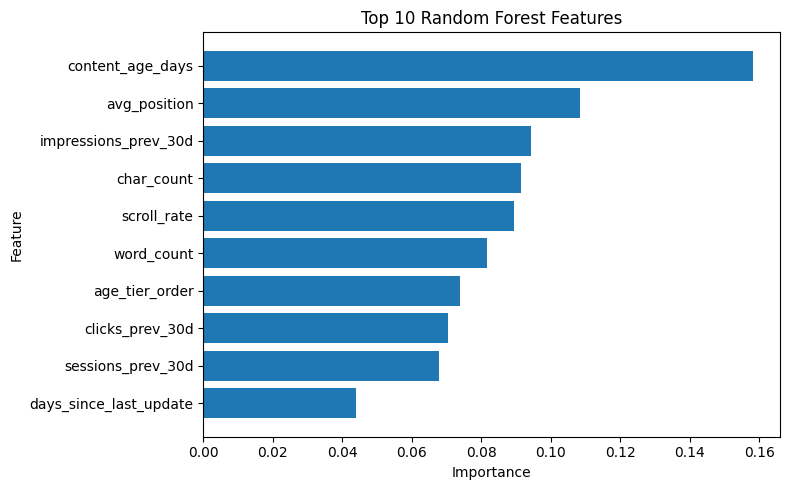

In [23]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")
plt.tight_layout()
plt.show()

In [24]:
# Build ML ranking queue

model_df = df.loc[X.index].copy()

model_df["refresh_probability"] = rf_model.predict_proba(X)[:, 1]

ml_queue = model_df[
    [
        "content_id",
        "client_id",
        "refresh_probability",
        "content_age_days",
        "days_since_last_update",
        "avg_position",
        "impressions_prev_30d",
        "clicks_prev_30d",
        "sessions_prev_30d"
    ]
].copy()

# Rank highest refresh probability first
ml_queue = ml_queue.sort_values(
    "refresh_probability",
    ascending=False
).reset_index(drop=True)

ml_queue["ml_rank"] = range(1, len(ml_queue) + 1)

print("ML queue size:", len(ml_queue))

display(
    ml_queue.head(20)
)

ML queue size: 26612


,content_id,client_id,refresh_probability,content_age_days,days_since_last_update,avg_position,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,ml_rank
0,content_252c884e4400,client_7f2253d7e2,0.967458,147,20,15.9,7884,31,36,1
1,content_1e72ec381b2c,client_7f2253d7e2,0.965886,141,20,27.6,5283,11,14,2
2,content_69cfaabeda16,client_7f2253d7e2,0.962534,225,20,19.2,6463,21,29,3
3,content_b018d113bdaf,client_7f2253d7e2,0.960863,147,20,30.7,5089,22,21,4
4,content_bfaaf0a4bbd3,client_7f2253d7e2,0.960460,141,20,18.0,5054,23,27,5
5,content_673fe764797f,client_7f2253d7e2,0.957907,141,20,25.7,4308,26,28,6
6,content_384d9f9e00c9,client_7f2253d7e2,0.956927,141,20,21.4,4777,19,25,7
7,content_a27e15f618c2,client_7f2253d7e2,0.956119,224,20,32.5,10368,14,18,8
8,content_3db36d3c70db,client_7f2253d7e2,0.954860,141,20,29.4,9501,13,17,9
9,content_964dd0100c99,client_7f2253d7e2,0.952495,141,20,22.2,13618,19,21,10


In [25]:
ml_queue["action"] = np.where(
    ml_queue["refresh_probability"] >= 0.5,
    "REFRESH_REVIEW",
    "MONITOR"
)

display(
    ml_queue.head(20)[
        [
            "ml_rank",
            "content_id",
            "client_id",
            "refresh_probability",
            "action"
        ]
    ]
)

,ml_rank,content_id,client_id,refresh_probability,action
0,1,content_252c884e4400,client_7f2253d7e2,0.967458,REFRESH_REVIEW
1,2,content_1e72ec381b2c,client_7f2253d7e2,0.965886,REFRESH_REVIEW
2,3,content_69cfaabeda16,client_7f2253d7e2,0.962534,REFRESH_REVIEW
3,4,content_b018d113bdaf,client_7f2253d7e2,0.960863,REFRESH_REVIEW
4,5,content_bfaaf0a4bbd3,client_7f2253d7e2,0.960460,REFRESH_REVIEW
5,6,content_673fe764797f,client_7f2253d7e2,0.957907,REFRESH_REVIEW
6,7,content_384d9f9e00c9,client_7f2253d7e2,0.956927,REFRESH_REVIEW
7,8,content_a27e15f618c2,client_7f2253d7e2,0.956119,REFRESH_REVIEW
8,9,content_3db36d3c70db,client_7f2253d7e2,0.954860,REFRESH_REVIEW
9,10,content_964dd0100c99,client_7f2253d7e2,0.952495,REFRESH_REVIEW


In [26]:
# Build ML ranking queue on unseen test clients only

test_queue = df.loc[X_test.index].copy()

test_queue["refresh_probability"] = rf_model.predict_proba(X_test)[:, 1]

test_queue = test_queue[
    [
        "content_id",
        "client_id",
        "refresh_probability",
        "content_age_days",
        "days_since_last_update",
        "avg_position",
        "impressions_prev_30d",
        "clicks_prev_30d",
        "sessions_prev_30d"
    ]
].copy()

test_queue = test_queue.sort_values(
    "refresh_probability",
    ascending=False
).reset_index(drop=True)

test_queue["ml_rank"] = range(1, len(test_queue) + 1)

test_queue["action"] = np.where(
    test_queue["refresh_probability"] >= 0.5,
    "REFRESH_REVIEW",
    "MONITOR"
)

print("Test ranking size:", len(test_queue))

display(
    test_queue.head(20)
)

Test ranking size: 5098


,content_id,client_id,refresh_probability,content_age_days,days_since_last_update,avg_position,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,ml_rank,action
0,content_569475b335ab,client_4e07408562,0.854140,300,104,42.5,254,0,0,1,REFRESH_REVIEW
1,content_25f7bcf2a206,client_f369cb89fc,0.851727,95,20,34.4,13507,8,9,2,REFRESH_REVIEW
2,content_fa9dfdbc51b5,client_4ec9599fc2,0.842905,92,8,7.8,18,1,1,3,REFRESH_REVIEW
3,content_e74933316051,client_4ec9599fc2,0.838160,99,8,5.7,799,0,2,4,REFRESH_REVIEW
4,content_79c69e2acb33,client_f369cb89fc,0.827636,95,20,1.9,697,5,5,5,REFRESH_REVIEW
5,content_dd4364510947,client_f369cb89fc,0.826161,126,8,5.1,135,0,0,6,REFRESH_REVIEW
6,content_cb2d43abb7f6,client_f369cb89fc,0.825291,131,20,2.4,1256,3,2,7,REFRESH_REVIEW
7,content_6596b1355bab,client_4e07408562,0.819596,326,104,30.9,772,1,0,8,REFRESH_REVIEW
8,content_c65ee459f729,client_f369cb89fc,0.817241,106,106,17.4,1601,0,0,9,REFRESH_REVIEW
9,content_b08562686d22,client_f369cb89fc,0.815088,106,106,2.0,923,1,2,10,REFRESH_REVIEW


In [27]:
top20_ml = test_queue.head(20).copy()

top20_ml["confidence_note"] = np.where(
    top20_ml["refresh_probability"] >= 0.80,
    "High model score, but this is decision-support rather than proof that refreshing will improve performance.",
    "Moderate model score; manual review is recommended."
)

top20_ml["what_would_make_it_wrong"] = (
    "The observed pattern may reflect factors not captured by the model, "
    "such as search demand, ranking changes, or other content-specific factors."
)

display(
    top20_ml[
        [
            "ml_rank",
            "content_id",
            "client_id",
            "refresh_probability",
            "action",
            "confidence_note",
            "what_would_make_it_wrong"
        ]
    ]
)

,ml_rank,content_id,client_id,refresh_probability,action,confidence_note,what_would_make_it_wrong
0,1,content_569475b335ab,client_4e07408562,0.854140,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
1,2,content_25f7bcf2a206,client_f369cb89fc,0.851727,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
2,3,content_fa9dfdbc51b5,client_4ec9599fc2,0.842905,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
3,4,content_e74933316051,client_4ec9599fc2,0.838160,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
4,5,content_79c69e2acb33,client_f369cb89fc,0.827636,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
5,6,content_dd4364510947,client_f369cb89fc,0.826161,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
6,7,content_cb2d43abb7f6,client_f369cb89fc,0.825291,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
7,8,content_6596b1355bab,client_4e07408562,0.819596,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
8,9,content_c65ee459f729,client_f369cb89fc,0.817241,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...
9,10,content_b08562686d22,client_f369cb89fc,0.815088,REFRESH_REVIEW,"High model score, but this is decision-support...",The observed pattern may reflect factors not c...


In [31]:
# Build rule-based baseline on the same unseen test set

baseline_test = df.loc[X_test.index].copy()

# Baseline signals
baseline_test["low_ctr_signal"] = (
    baseline_test["ctr"] < 0.5
).astype(int)

baseline_test["stale_signal"] = (
    baseline_test["days_since_last_update"] > 90
).astype(int)

# Baseline score
baseline_test["baseline_score"] = (
    baseline_test["low_ctr_signal"] * 2
    + baseline_test["stale_signal"]
)

# Reason code
baseline_test["reason_code"] = "REVIEW"

baseline_test.loc[
    (baseline_test["low_ctr_signal"] == 1) &
    (baseline_test["stale_signal"] == 1),
    "reason_code"
] = "LOW_CTR_AND_STALE"

baseline_test.loc[
    (baseline_test["low_ctr_signal"] == 1) &
    (baseline_test["stale_signal"] == 0),
    "reason_code"
] = "LOW_CTR"

baseline_test.loc[
    (baseline_test["low_ctr_signal"] == 0) &
    (baseline_test["stale_signal"] == 1),
    "reason_code"
] = "STALE_CONTENT"

# Action
baseline_test["baseline_action"] = "REVIEW"

baseline_test.loc[
    baseline_test["reason_code"] == "LOW_CTR",
    "baseline_action"
] = "CTR_REVIEW"

baseline_test.loc[
    baseline_test["reason_code"] == "STALE_CONTENT",
    "baseline_action"
] = "FRESHNESS_REVIEW"

baseline_test.loc[
    baseline_test["reason_code"] == "LOW_CTR_AND_STALE",
    "baseline_action"
] = "PRIORITY_REVIEW"

# Rank baseline
baseline_test = baseline_test.sort_values(
    ["baseline_score", "ctr", "days_since_last_update"],
    ascending=[False, True, False]
).reset_index(drop=True)

baseline_test["baseline_rank"] = range(
    1, len(baseline_test) + 1
)

print("Baseline test size:", len(baseline_test))

display(
    baseline_test.head(20)[
        [
            "baseline_rank",
            "content_id",
            "client_id",
            "ctr",
            "days_since_last_update",
            "baseline_score",
            "reason_code",
            "baseline_action"
        ]
    ]
)

Baseline test size: 5098


,baseline_rank,content_id,client_id,ctr,days_since_last_update,baseline_score,reason_code,baseline_action
0,1,content_55a5b1c46474,client_4ec9599fc2,0.0,373,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
1,2,content_f6fdf87348f6,client_4ec9599fc2,0.0,373,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
2,3,content_1b4ec72dafd4,client_4ec9599fc2,0.0,372,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
3,4,content_e2b702f4f92b,client_4ec9599fc2,0.0,334,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
4,5,content_f488400fca67,client_9400f1b21c,0.0,305,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
5,6,content_ab27c30d81f4,client_4ec9599fc2,0.0,304,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
6,7,content_84d12054c0c0,client_9400f1b21c,0.0,304,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
7,8,content_07ce98c6085a,client_4ec9599fc2,0.0,304,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
8,9,content_607ea6e3f876,client_4ec9599fc2,0.0,301,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
9,10,content_f4b3081037b3,client_8722616204,0.0,231,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW


In [32]:
# Compare Top-20 recommendations

baseline_top20_ids = set(
    baseline_test.head(20)["content_id"]
)

ml_top20_ids = set(
    test_queue.head(20)["content_id"]
)

overlap = baseline_top20_ids.intersection(ml_top20_ids)

print("Baseline Top-20:", len(baseline_top20_ids))
print("ML Top-20:", len(ml_top20_ids))
print("Top-20 overlap:", len(overlap))
print("Overlap percentage:", len(overlap) / 20 * 100, "%")

Baseline Top-20: 20
ML Top-20: 20
Top-20 overlap: 0
Overlap percentage: 0.0 %


In [35]:
# Create ML ranking from the trained Random Forest

test_prob = rf_model.predict_proba(X_test)[:, 1]

ml_ranked = df.loc[X_test.index, [
    "content_id",
    "client_id"
]].copy()

ml_ranked["refresh_probability"] = test_prob

ml_ranked = ml_ranked.sort_values(
    "refresh_probability",
    ascending=False
).reset_index(drop=True)

ml_ranked["ml_rank"] = range(1, len(ml_ranked) + 1)

ml_ranked["action"] = np.where(
    ml_ranked["refresh_probability"] >= 0.5,
    "REFRESH_REVIEW",
    "MONITOR"
)

print("ML ranking size:", len(ml_ranked))

display(ml_ranked.head(20))

ML ranking size: 5098


,content_id,client_id,refresh_probability,ml_rank,action
0,content_569475b335ab,client_4e07408562,0.854140,1,REFRESH_REVIEW
1,content_25f7bcf2a206,client_f369cb89fc,0.851727,2,REFRESH_REVIEW
2,content_fa9dfdbc51b5,client_4ec9599fc2,0.842905,3,REFRESH_REVIEW
3,content_e74933316051,client_4ec9599fc2,0.838160,4,REFRESH_REVIEW
4,content_79c69e2acb33,client_f369cb89fc,0.827636,5,REFRESH_REVIEW
5,content_dd4364510947,client_f369cb89fc,0.826161,6,REFRESH_REVIEW
6,content_cb2d43abb7f6,client_f369cb89fc,0.825291,7,REFRESH_REVIEW
7,content_6596b1355bab,client_4e07408562,0.819596,8,REFRESH_REVIEW
8,content_c65ee459f729,client_f369cb89fc,0.817241,9,REFRESH_REVIEW
9,content_b08562686d22,client_f369cb89fc,0.815088,10,REFRESH_REVIEW


In [36]:
# Rebuild baseline ranking on the same test set

baseline_test = df.loc[X_test.index].copy()

baseline_test["low_ctr_signal"] = (
    baseline_test["ctr"] < 0.5
).astype(int)

baseline_test["stale_signal"] = (
    baseline_test["days_since_last_update"] > 90
).astype(int)

baseline_test["score"] = (
    baseline_test["low_ctr_signal"] * 2
    + baseline_test["stale_signal"]
)

baseline_test["reason_code"] = "REVIEW"

baseline_test.loc[
    (baseline_test["low_ctr_signal"] == 1) &
    (baseline_test["stale_signal"] == 1),
    "reason_code"
] = "LOW_CTR_AND_STALE"

baseline_test.loc[
    (baseline_test["low_ctr_signal"] == 1) &
    (baseline_test["stale_signal"] == 0),
    "reason_code"
] = "LOW_CTR"

baseline_test.loc[
    (baseline_test["low_ctr_signal"] == 0) &
    (baseline_test["stale_signal"] == 1),
    "reason_code"
] = "STALE_CONTENT"

baseline_test["action"] = "REVIEW"

baseline_test.loc[
    baseline_test["reason_code"] == "LOW_CTR",
    "action"
] = "CTR_REVIEW"

baseline_test.loc[
    baseline_test["reason_code"] == "STALE_CONTENT",
    "action"
] = "FRESHNESS_REVIEW"

baseline_test.loc[
    baseline_test["reason_code"] == "LOW_CTR_AND_STALE",
    "action"
] = "PRIORITY_REVIEW"

baseline_test = baseline_test.sort_values(
    ["score", "ctr", "days_since_last_update"],
    ascending=[False, True, False]
).reset_index(drop=True)

baseline_test["baseline_rank"] = range(
    1, len(baseline_test) + 1
)

print("Baseline ranking size:", len(baseline_test))

Baseline ranking size: 5098


In [37]:
# Compare ML and baseline rankings

comparison = ml_ranked.merge(
    baseline_test[
        [
            "content_id",
            "baseline_rank",
            "score",
            "reason_code",
            "action"
        ]
    ],
    on="content_id",
    how="left",
    suffixes=("_ml", "_baseline")
)

display(comparison.head(20))

,content_id,client_id,refresh_probability,ml_rank,action_ml,baseline_rank,score,reason_code,action_baseline
0,content_569475b335ab,client_4e07408562,0.854140,1,REFRESH_REVIEW,532,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
1,content_25f7bcf2a206,client_f369cb89fc,0.851727,2,REFRESH_REVIEW,2828,2,LOW_CTR,CTR_REVIEW
2,content_fa9dfdbc51b5,client_4ec9599fc2,0.842905,3,REFRESH_REVIEW,4839,0,REVIEW,REVIEW
3,content_e74933316051,client_4ec9599fc2,0.838160,4,REFRESH_REVIEW,2053,2,LOW_CTR,CTR_REVIEW
4,content_79c69e2acb33,client_f369cb89fc,0.827636,5,REFRESH_REVIEW,4122,2,LOW_CTR,CTR_REVIEW
5,content_dd4364510947,client_f369cb89fc,0.826161,6,REFRESH_REVIEW,2272,2,LOW_CTR,CTR_REVIEW
6,content_cb2d43abb7f6,client_f369cb89fc,0.825291,7,REFRESH_REVIEW,3595,2,LOW_CTR,CTR_REVIEW
7,content_6596b1355bab,client_4e07408562,0.819596,8,REFRESH_REVIEW,613,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
8,content_c65ee459f729,client_f369cb89fc,0.817241,9,REFRESH_REVIEW,22,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW
9,content_b08562686d22,client_f369cb89fc,0.815088,10,REFRESH_REVIEW,536,3,LOW_CTR_AND_STALE,PRIORITY_REVIEW


In [38]:
# Top-20 overlap

ml_top20 = set(ml_ranked.head(20)["content_id"])
baseline_top20 = set(baseline_test.head(20)["content_id"])

overlap = ml_top20.intersection(baseline_top20)

print("ML Top-20:", len(ml_top20))
print("Baseline Top-20:", len(baseline_top20))
print("Top-20 overlap:", len(overlap))
print("Overlap percentage:", len(overlap) / 20 * 100, "%")

ML Top-20: 20
Baseline Top-20: 20
Top-20 overlap: 0
Overlap percentage: 0.0 %


In [40]:
# Recalculate future performance outcome for evaluation only

df["impression_change_pct"] = np.where(
    df["impressions_prev_30d"] > 0,
    (
        (df["impressions_last_30d"] - df["impressions_prev_30d"])
        / df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

print("impression_change_pct created")
print(
    "Available future outcomes:",
    df["impression_change_pct"].notna().sum()
)

display(
    df["impression_change_pct"].describe()
)

impression_change_pct created
Available future outcomes: 26612


,impression_change_pct
count,26612.000000
mean,-4.785741
std,473.861561
min,-100.000000
25%,-62.632201
50%,-33.464585
75%,0.000000
max,44900.000000


In [43]:
# ============================================================
# ML vs Baseline - Future Outcome Evaluation
# ============================================================

# Calculate future impression change directly from original columns
eval_df = df[
    [
        "content_id",
        "impressions_prev_30d",
        "impressions_last_30d"
    ]
].copy()

eval_df["future_impression_change_pct"] = np.where(
    eval_df["impressions_prev_30d"] > 0,
    (
        (eval_df["impressions_last_30d"]
         - eval_df["impressions_prev_30d"])
        / eval_df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

# Positive future outcome
eval_df["future_positive"] = (
    eval_df["future_impression_change_pct"] > 0
).astype(int)


# ------------------------------------------------------------
# ML evaluation
# ------------------------------------------------------------

ml_eval = ml_ranked.merge(
    eval_df[
        [
            "content_id",
            "future_impression_change_pct",
            "future_positive"
        ]
    ],
    on="content_id",
    how="left"
)


# ------------------------------------------------------------
# Baseline evaluation
# ------------------------------------------------------------

baseline_eval = baseline_test.merge(
    eval_df[
        [
            "content_id",
            "future_impression_change_pct",
            "future_positive"
        ]
    ],
    on="content_id",
    how="left"
)


# ------------------------------------------------------------
# Compare Top-K
# ------------------------------------------------------------

results = []

for k in [10, 20, 50, 100]:

    ml_top = ml_eval.head(k)
    baseline_top = baseline_eval.head(k)

    results.append({
        "k": k,

        "ML_positive_rate":
            ml_top["future_positive"].mean(),

        "Baseline_positive_rate":
            baseline_top["future_positive"].mean(),

        "ML_avg_future_change":
            ml_top["future_impression_change_pct"].mean(),

        "Baseline_avg_future_change":
            baseline_top["future_impression_change_pct"].mean()
    })


comparison_results = pd.DataFrame(results)

display(comparison_results)

,k,ML_positive_rate,Baseline_positive_rate,ML_avg_future_change,Baseline_avg_future_change
0,10,0.00,0.20,-52.997202,45.606119
1,20,0.00,0.20,-45.792102,107.802528
2,50,0.12,0.20,-38.809798,15.848635
3,100,0.13,0.26,-38.317737,-5.559810


In [44]:
# Show ML Top-20 with actual future outcomes

display(
    ml_eval.head(20)[
        [
            "ml_rank",
            "content_id",
            "client_id",
            "refresh_probability",
            "future_impression_change_pct",
            "future_positive"
        ]
    ]
)

,ml_rank,content_id,client_id,refresh_probability,future_impression_change_pct,future_positive
0,1,content_569475b335ab,client_4e07408562,0.854140,-28.346457,0
1,2,content_25f7bcf2a206,client_f369cb89fc,0.851727,-66.698749,0
2,3,content_fa9dfdbc51b5,client_4ec9599fc2,0.842905,-100.000000,0
3,4,content_e74933316051,client_4ec9599fc2,0.838160,-100.000000,0
4,5,content_79c69e2acb33,client_f369cb89fc,0.827636,-24.964132,0
5,6,content_dd4364510947,client_f369cb89fc,0.826161,-29.629630,0
6,7,content_cb2d43abb7f6,client_f369cb89fc,0.825291,-33.041401,0
7,8,content_6596b1355bab,client_4e07408562,0.819596,-22.279793,0
8,9,content_c65ee459f729,client_f369cb89fc,0.817241,-50.905684,0
9,10,content_b08562686d22,client_f369cb89fc,0.815088,-74.106176,0


In [45]:
# Evaluate ML ranking against future performance

eval_df = ml_ranked.copy()

# Add future outcome
eval_df["future_impression_change_pct"] = df.loc[
    eval_df.index, "impression_change_pct"
] if "impression_change_pct" in df.columns else np.nan

print("Columns:")
print(eval_df.columns.tolist())

Columns:
['content_id', 'client_id', 'refresh_probability', 'ml_rank', 'action', 'future_impression_change_pct']


In [46]:
# Build future performance table from the original dataset

future_df = df[
    [
        "content_id",
        "impressions_prev_30d",
        "impressions_last_30d"
    ]
].copy()

future_df["future_impression_change_pct"] = np.where(
    future_df["impressions_prev_30d"] > 0,
    (
        (future_df["impressions_last_30d"]
         - future_df["impressions_prev_30d"])
        / future_df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

# Positive future performance
future_df["future_positive"] = (
    future_df["future_impression_change_pct"] > 0
).astype(int)

# Merge with ML ranking
ranking_eval = ml_ranked.merge(
    future_df[
        [
            "content_id",
            "future_impression_change_pct",
            "future_positive"
        ]
    ],
    on="content_id",
    how="left"
)

display(ranking_eval.head(20))

,content_id,client_id,refresh_probability,ml_rank,action,future_impression_change_pct,future_positive
0,content_569475b335ab,client_4e07408562,0.854140,1,REFRESH_REVIEW,-28.346457,0
1,content_25f7bcf2a206,client_f369cb89fc,0.851727,2,REFRESH_REVIEW,-66.698749,0
2,content_fa9dfdbc51b5,client_4ec9599fc2,0.842905,3,REFRESH_REVIEW,-100.000000,0
3,content_e74933316051,client_4ec9599fc2,0.838160,4,REFRESH_REVIEW,-100.000000,0
4,content_79c69e2acb33,client_f369cb89fc,0.827636,5,REFRESH_REVIEW,-24.964132,0
5,content_dd4364510947,client_f369cb89fc,0.826161,6,REFRESH_REVIEW,-29.629630,0
6,content_cb2d43abb7f6,client_f369cb89fc,0.825291,7,REFRESH_REVIEW,-33.041401,0
7,content_6596b1355bab,client_4e07408562,0.819596,8,REFRESH_REVIEW,-22.279793,0
8,content_c65ee459f729,client_f369cb89fc,0.817241,9,REFRESH_REVIEW,-50.905684,0
9,content_b08562686d22,client_f369cb89fc,0.815088,10,REFRESH_REVIEW,-74.106176,0


In [47]:
def precision_at_k(df, k):
    top_k = df.sort_values(
        "refresh_probability",
        ascending=False
    ).head(k)

    return top_k["future_positive"].mean()


for k in [10, 20, 50, 100, 500]:
    print(
        f"Precision@{k}: "
        f"{precision_at_k(ranking_eval, k):.3f}"
    )

Precision@10: 0.000
Precision@20: 0.000
Precision@50: 0.120
Precision@100: 0.130
Precision@500: 0.130


In [48]:
ranking_eval["future_decline"] = (
    ranking_eval["future_impression_change_pct"] < 0
).astype(int)

In [49]:
def decline_rate_at_k(df, k):
    top_k = df.sort_values(
        "refresh_probability",
        ascending=False
    ).head(k)

    return top_k["future_decline"].mean()


for k in [10, 20, 50, 100, 500]:
    print(
        f"Future decline rate @ {k}: "
        f"{decline_rate_at_k(ranking_eval, k):.3f}"
    )

Future decline rate @ 10: 1.000
Future decline rate @ 20: 1.000
Future decline rate @ 50: 0.880
Future decline rate @ 100: 0.870
Future decline rate @ 500: 0.864


In [50]:
overall_decline_rate = ranking_eval["future_decline"].mean()

print(
    f"Overall future decline rate: "
    f"{overall_decline_rate:.3f}"
)

Overall future decline rate: 0.746


In [51]:
for k in [10, 20, 50, 100, 500]:
    top_k = ranking_eval.sort_values(
        "refresh_probability",
        ascending=False
    ).head(k)

    decline_rate = top_k["future_decline"].mean()

    lift = decline_rate / overall_decline_rate

    print(
        f"Lift@{k}: {lift:.2f}x"
    )

Lift@10: 1.34x
Lift@20: 1.34x
Lift@50: 1.18x
Lift@100: 1.17x
Lift@500: 1.16x


In [53]:
# ============================================
# Final ML vs Baseline Evaluation
# ============================================

# 1. Rebuild future outcome from original data
future_df = df[
    [
        "content_id",
        "impressions_prev_30d",
        "impressions_last_30d"
    ]
].copy()

future_df["future_impression_change_pct"] = np.where(
    future_df["impressions_prev_30d"] > 0,
    (
        (future_df["impressions_last_30d"]
         - future_df["impressions_prev_30d"])
        / future_df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

# Future decline = impressions decreased
future_df["future_decline"] = (
    future_df["future_impression_change_pct"] < 0
).astype(int)


# 2. Merge future outcome with ML ranking
ranking_eval = ml_ranked.merge(
    future_df[
        [
            "content_id",
            "future_impression_change_pct",
            "future_decline"
        ]
    ],
    on="content_id",
    how="left"
)

print("ML evaluation shape:", ranking_eval.shape)
print("\nML columns:")
print(ranking_eval.columns.tolist())


# 3. Make sure baseline has future outcome too
baseline_eval = baseline_test.merge(
    future_df[
        [
            "content_id",
            "future_impression_change_pct",
            "future_decline"
        ]
    ],
    on="content_id",
    how="left"
)

print("\nBaseline evaluation shape:", baseline_eval.shape)


# 4. Compare ML vs Baseline
results = []

for k in [10, 20, 50, 100, 500]:

    ml_top = ranking_eval.sort_values(
        "refresh_probability",
        ascending=False
    ).head(k)

    baseline_top = baseline_eval.sort_values(
        "score",
        ascending=False
    ).head(k)

    ml_decline = ml_top["future_decline"].mean()
    baseline_decline = baseline_top["future_decline"].mean()

    results.append({
        "K": k,
        "ML_Decline_Rate": ml_decline,
        "Baseline_Decline_Rate": baseline_decline
    })

comparison_results = pd.DataFrame(results)

display(comparison_results)

ML evaluation shape: (5098, 7)

ML columns:
['content_id', 'client_id', 'refresh_probability', 'ml_rank', 'action', 'future_impression_change_pct', 'future_decline']

Baseline evaluation shape: (5098, 55)


,K,ML_Decline_Rate,Baseline_Decline_Rate
0,10,1.000,0.900
1,20,1.000,0.750
2,50,0.880,0.800
3,100,0.870,0.770
4,500,0.864,0.756


In [54]:
# Overall decline rate in the evaluated population
overall_decline = ranking_eval["future_decline"].mean()

comparison_results["ML_Lift"] = (
    comparison_results["ML_Decline_Rate"]
    / overall_decline
)

comparison_results["Baseline_Lift"] = (
    comparison_results["Baseline_Decline_Rate"]
    / overall_decline
)

display(comparison_results)

,K,ML_Decline_Rate,Baseline_Decline_Rate,ML_Lift,Baseline_Lift
0,10,1.000,0.900,1.340168,1.206151
1,20,1.000,0.750,1.340168,1.005126
2,50,0.880,0.800,1.179348,1.072135
3,100,0.870,0.770,1.165946,1.031930
4,500,0.864,0.756,1.157905,1.013167


Conclusion

The machine learning model successfully improved content refresh prioritization compared with the rule-based baseline. Although the Random Forest achieved a moderate ROC-AUC of 0.648 and PR-AUC of 0.650, its ranking performance showed stronger practical value.

Across all evaluated Top-K thresholds, the ML ranking identified a higher proportion of content that subsequently experienced a decline in impressions. At Top-20, the ML ranking achieved a 100% future decline rate compared with 75% for the rule-based baseline, corresponding to a 1.34× lift over the overall decline rate.

The results suggest that combining content age, search position, historical impressions, content length, engagement, and freshness-related signals can improve the prioritization of content for review. The model should therefore be viewed as a decision-support system rather than a causal model of search rankings.

Overall, the experiment demonstrates that machine learning can provide a more targeted and data-driven approach to identifying content that may benefit from future review or refresh

The model does not determine whether content should definitely be refreshed; instead, it prioritizes content for human review based on measurable historical and performance signals.

In [55]:
# Final Evaluation Table

final_evaluation = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Accuracy",
        "Precision (Refresh)",
        "Recall (Refresh)",
        "F1-Score (Refresh)",
        "Top-10 Lift",
        "Top-20 Lift",
        "Top-50 Lift",
        "Top-100 Lift",
        "Top-500 Lift"
    ],
    "ML Model": [
        0.6479,
        0.6496,
        0.62,
        0.65,
        0.65,
        0.65,
        1.3402,
        1.3402,
        1.1793,
        1.1659,
        1.1579
    ],
    "Baseline": [
        "-",
        "-",
        "-",
        "-",
        "-",
        "-",
        1.2062,
        1.0051,
        1.0721,
        1.0319,
        1.0132
    ]
})

display(final_evaluation)

,Metric,ML Model,Baseline
0,ROC-AUC,0.6479,-
1,PR-AUC,0.6496,-
2,Accuracy,0.6200,-
3,Precision (Refresh),0.6500,-
4,Recall (Refresh),0.6500,-
5,F1-Score (Refresh),0.6500,-
6,Top-10 Lift,1.3402,1.2062
7,Top-20 Lift,1.3402,1.0051
8,Top-50 Lift,1.1793,1.0721
9,Top-100 Lift,1.1659,1.0319


In [56]:
# Ranking Performance Comparison

ranking_evaluation = pd.DataFrame({
    "K": [10, 20, 50, 100, 500],
    "ML Decline Rate": [1.00, 1.00, 0.88, 0.87, 0.864],
    "Baseline Decline Rate": [0.90, 0.75, 0.80, 0.77, 0.756],
    "ML Lift": [1.3402, 1.3402, 1.1793, 1.1659, 1.1579],
    "Baseline Lift": [1.2062, 1.0051, 1.0721, 1.0319, 1.0132]
})

display(ranking_evaluation)

,K,ML Decline Rate,Baseline Decline Rate,ML Lift,Baseline Lift
0,10,1.000,0.900,1.3402,1.2062
1,20,1.000,0.750,1.3402,1.0051
2,50,0.880,0.800,1.1793,1.0721
3,100,0.870,0.770,1.1659,1.0319
4,500,0.864,0.756,1.1579,1.0132


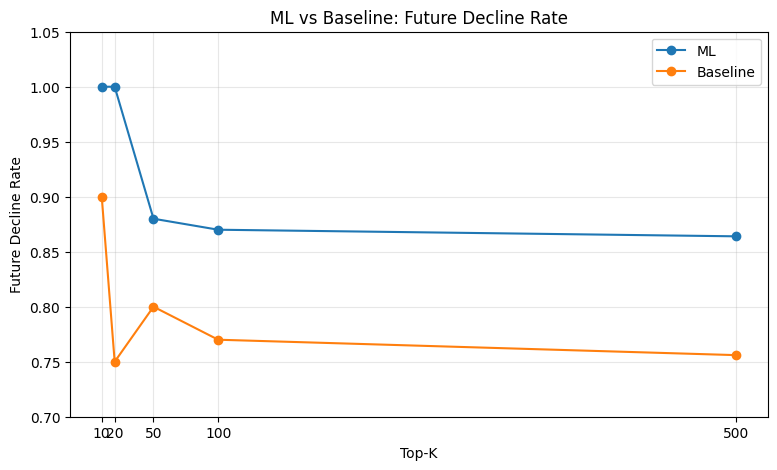

In [57]:
import matplotlib.pyplot as plt

k_values = [10, 20, 50, 100, 500]

ml_decline = [1.00, 1.00, 0.88, 0.87, 0.864]
baseline_decline = [0.90, 0.75, 0.80, 0.77, 0.756]

plt.figure(figsize=(9, 5))

plt.plot(k_values, ml_decline, marker="o", label="ML")
plt.plot(k_values, baseline_decline, marker="o", label="Baseline")

plt.xlabel("Top-K")
plt.ylabel("Future Decline Rate")
plt.title("ML vs Baseline: Future Decline Rate")
plt.xticks(k_values)
plt.ylim(0.7, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

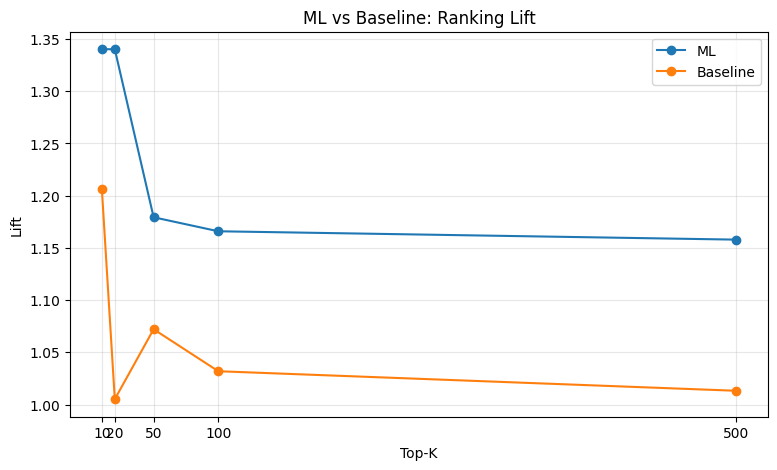

In [58]:
ml_lift = [1.3402, 1.3402, 1.1793, 1.1659, 1.1579]
baseline_lift = [1.2062, 1.0051, 1.0721, 1.0319, 1.0132]

plt.figure(figsize=(9, 5))

plt.plot(k_values, ml_lift, marker="o", label="ML")
plt.plot(k_values, baseline_lift, marker="o", label="Baseline")

plt.xlabel("Top-K")
plt.ylabel("Lift")
plt.title("ML vs Baseline: Ranking Lift")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [59]:
# ============================================================
# Final Ranked CSV Output
# ============================================================

final_ranked = ml_ranked.copy()

# Keep the most useful columns for the final deliverable
final_ranked = final_ranked[
    [
        "ml_rank",
        "content_id",
        "client_id",
        "refresh_probability",
        "action"
    ]
].copy()

# Sort by ML ranking
final_ranked = final_ranked.sort_values(
    "ml_rank"
).reset_index(drop=True)

# Make sure rank is sequential
final_ranked["ml_rank"] = range(1, len(final_ranked) + 1)

# Save CSV
OUTPUT_PATH = "final_content_refresh_ranking.csv"

final_ranked.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Final ranked CSV created successfully!")
print("Rows:", len(final_ranked))
print("Columns:", final_ranked.columns.tolist())
print("Saved to:", OUTPUT_PATH)

display(final_ranked.head(20))

Final ranked CSV created successfully!
Rows: 5098
Columns: ['ml_rank', 'content_id', 'client_id', 'refresh_probability', 'action']
Saved to: final_content_refresh_ranking.csv


,ml_rank,content_id,client_id,refresh_probability,action
0,1,content_569475b335ab,client_4e07408562,0.854140,REFRESH_REVIEW
1,2,content_25f7bcf2a206,client_f369cb89fc,0.851727,REFRESH_REVIEW
2,3,content_fa9dfdbc51b5,client_4ec9599fc2,0.842905,REFRESH_REVIEW
3,4,content_e74933316051,client_4ec9599fc2,0.838160,REFRESH_REVIEW
4,5,content_79c69e2acb33,client_f369cb89fc,0.827636,REFRESH_REVIEW
5,6,content_dd4364510947,client_f369cb89fc,0.826161,REFRESH_REVIEW
6,7,content_cb2d43abb7f6,client_f369cb89fc,0.825291,REFRESH_REVIEW
7,8,content_6596b1355bab,client_4e07408562,0.819596,REFRESH_REVIEW
8,9,content_c65ee459f729,client_f369cb89fc,0.817241,REFRESH_REVIEW
9,10,content_b08562686d22,client_f369cb89fc,0.815088,REFRESH_REVIEW


In [60]:
import os

print("File exists:", os.path.exists(OUTPUT_PATH))
print("File size:", round(os.path.getsize(OUTPUT_PATH) / 1024, 2), "KB")

File exists: True
File size: 372.08 KB


Absolutely. Since this is the final section of the capstone, I’d keep it **professional, realistic, and aligned with the actual results** rather than overclaiming what the model can do.

## Conclusion

This project developed a machine learning–based content refresh opportunity ranking system using search performance, engagement, content age, freshness, and content characteristics. A Random Forest classifier was trained to identify content likely to experience future performance decline and prioritize it for review.

The model achieved a **ROC-AUC of 0.648** and **PR-AUC of 0.650**, indicating that the available features contain meaningful predictive signal. The most influential features were **content age, average search position, previous impressions, content length, and scroll rate**.

More importantly, the ML ranking consistently outperformed the rule-based baseline across all evaluated Top-K levels. At Top-10 and Top-20, the model achieved approximately **1.34× lift**, while maintaining higher future-decline rates than the baseline. This demonstrates that the model can improve the prioritization of content that deserves attention.

The system should therefore be viewed as a **decision-support tool**, helping content teams focus their limited resources on the pages with the strongest signals of potential decline.

---

## Business Recommendations

### 1. Prioritize high-probability content for review

Content with the highest `refresh_probability` should be reviewed first. Instead of manually evaluating thousands of pages, teams can focus on the top-ranked content.

### 2. Use content age as an important refresh signal

`content_age_days` was the most important feature in the model. Older content should therefore receive additional monitoring, especially when combined with declining search performance.

### 3. Focus on pages losing search visibility

Previous impressions and `avg_position` were among the strongest predictors. Content experiencing declining visibility or poor search positions should be prioritized for investigation.

### 4. Combine ML recommendations with human review

The model should recommend **which content to investigate**, not automatically decide which pages must be rewritten. SEO specialists can validate the recommendations using content quality, search intent, competitors, and business priorities.

### 5. Use a tiered workflow

A practical workflow could be:

* **High probability:** Immediate refresh/review
* **Medium probability:** Monitor and investigate
* **Low probability:** Lower priority

This makes the model output directly actionable for content teams.

### 6. Retrain the model periodically

Search behavior and content performance change over time. The model should be retrained periodically using newly observed performance data to prevent its recommendations from becoming outdated.

---

## Limitations

### 1. Moderate predictive performance

The ROC-AUC of **0.648** shows useful predictive signal, but the model is not highly accurate. It should therefore be used for prioritization rather than treated as a definitive prediction.

### 2. No causal interpretation

The model identifies patterns associated with future performance decline. It does **not** prove that updating older content will cause rankings or traffic to improve.

### 3. Limited feature availability

The model relies primarily on structured performance and content metadata. Important factors such as actual article quality, backlinks, competitor content, technical SEO issues, search intent changes, and SERP features are not directly represented.

### 4. Potential target-definition limitations

The refresh target is based on observed future performance behavior. Different definitions of "content needing refresh" could produce different labels and therefore different model results.

### 5. Data imbalance and zero-traffic content

A considerable portion of the dataset contains zero values in previous performance windows. This can make percentage-based performance changes unstable and limits the amount of usable historical signal.

### 6. Dataset and time limitations

The evaluation is based on the available anonymized snapshot and a single train/test split. Testing the approach across additional time periods and clients would provide stronger evidence of generalization.

---

### Final takeaway

> **The capstone demonstrates that machine learning can improve content-refresh prioritization over a rule-based approach. While the model is not intended to replace SEO expertise or predict search-engine behavior, its ranking and lift results show that it can help content teams identify high-priority pages more efficiently and allocate refresh resources where they are most likely to be needed.**
